In [29]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import shap

core_df = pd.read_csv('feature_matrix.csv')
edu_df = pd.read_csv('edu_job_features.csv')

core_df = core_df.dropna(subset=['is_success']).copy()

columns_to_drop = [
    'funding_total_usd', 
    'log_funding', 
    'num_funding_rounds', 
    'company_age_months',
    'company_uuid',
    'is_success'
]

lgb_params = {
    'random_state': 42,
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 6
}

## Exploratory Data Analysis

/var/folders/99/8q4b4cy9787b9wnfsv_pcm4c0000gn/T/ipykernel_86793/4061840182.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=binary_df, x='Success_Rate', y='Label', palette='coolwarm')


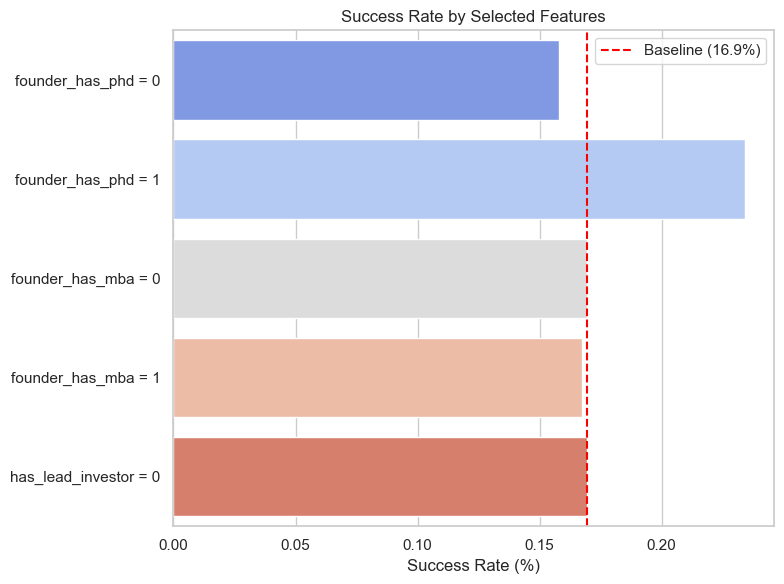

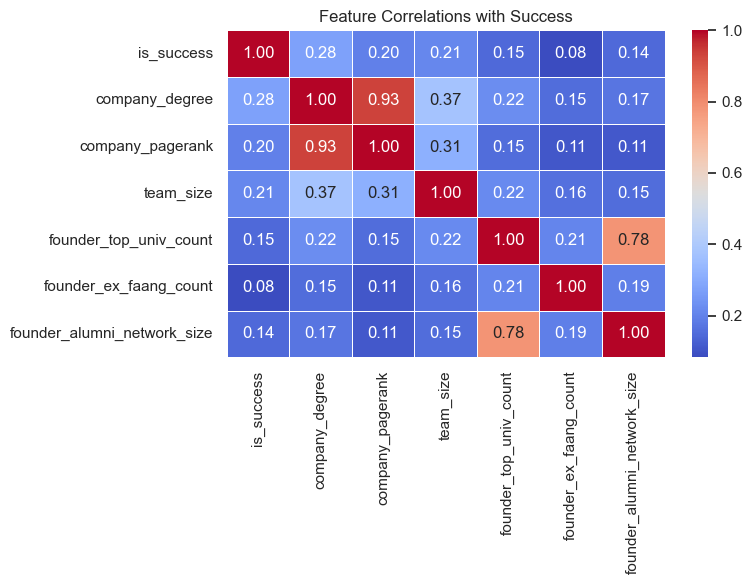

In [30]:
df_eda = pd.merge(core_df, edu_df, on='company_uuid', how='left')
df_eda = df_eda.dropna(subset=['is_success']).copy()

#success rate vs selected features
baseline_success = df_eda['is_success'].mean()

binary_cols = ['founder_has_phd', 'founder_has_mba', 'num_lead_investors']
df_eda['has_lead_investor'] = (df_eda['num_lead_investors'] > 0).astype(int)
    
plot_data = []
for col in ['founder_has_phd', 'founder_has_mba', 'has_lead_investor']:
    rates = df_eda.groupby(col)['is_success'].mean().reset_index()
    rates.columns = ['Value', 'Success_Rate']
    rates['Feature'] = col
    plot_data.append(rates)
        
binary_df = pd.concat(plot_data)
binary_df['Label'] = binary_df.apply(lambda x: f"{x['Feature']} = {x['Value']}", axis=1)

plt.figure(figsize=(8, 6))
sns.barplot(data=binary_df, x='Success_Rate', y='Label', palette='coolwarm')
plt.axvline(baseline_success, color='red', linestyle='--', label=f'Baseline ({baseline_success:.1%})')
plt.title('Success Rate by Selected Features')
plt.xlabel('Success Rate (%)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

#correlation of top features
plt.figure(figsize=(8, 6))
subset_cols = ['is_success', 'company_degree', 'company_pagerank', 'team_size', 
                   'founder_top_univ_count', 'founder_ex_faang_count', 'founder_alumni_network_size']
existing_cols = [c for c in subset_cols if c in df.columns]
corr = df_eda[existing_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlations with Success')
plt.tight_layout()
plt.show()

## V1: Core Features Incl. EDU/JOB Features

In [31]:
combined_df = pd.merge(core_df, edu_df, on='company_uuid', how='left')

X_combined = combined_df.drop(columns=[c for c in columns_to_drop if c in combined_df.columns])
y_combined = combined_df['is_success']

#split combined data
X_train_comb, X_test_comb, _, _ = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

model_comb = lgb.LGBMClassifier(**lgb_params)
model_comb.fit(X_train_comb, y_train)

roc_auc_comb = roc_auc_score(y_test, model_comb.predict_proba(X_test_comb)[:, 1])
print(f"Number of features used: {X_combined.shape[1]}")
print(f"Test ROC-AUC:            {roc_auc_comb:.4f}")

[LightGBM] [Info] Number of positive: 893, number of negative: 4381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3974
[LightGBM] [Info] Number of data points in the train set: 5274, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.169321 -> initscore=-1.590446
[LightGBM] [Info] Start training from score -1.590446
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

## V2: Excl. EDU/JOB Features

In [32]:
X_core = core_df.drop(columns=[c for c in columns_to_drop if c in core_df.columns])
y_core = core_df['is_success']

#stratified
X_train_core, X_test_core, y_train, y_test = train_test_split(
    X_core, y_core, test_size=0.2, random_state=42, stratify=y_core
)

model_core = lgb.LGBMClassifier(**lgb_params)
model_core.fit(X_train_core, y_train)

roc_auc_core = roc_auc_score(y_test, model_core.predict_proba(X_test_core)[:, 1])
print(f"Number of features used: {X_core.shape[1]}")
print(f"Test ROC-AUC:            {roc_auc_core:.4f}")

[LightGBM] [Info] Number of positive: 893, number of negative: 4381
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2388
[LightGBM] [Info] Number of data points in the train set: 5274, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.169321 -> initscore=-1.590446
[LightGBM] [Info] Start training from score -1.590446
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## Stats

In [33]:
print("\n" + "="*45)
print("FINAL COMPARISON SUMMARY")
print("="*45)
print(f"Core Features Only:      {roc_auc_core:.4f}")
print(f"Core + Edu/Job Features: {roc_auc_comb:.4f}")

improvement = roc_auc_comb - roc_auc_core
print(f"Improvement:             {improvement:+.4f} AUC points")


FINAL COMPARISON SUMMARY
Core Features Only:      0.7941
Core + Edu/Job Features: 0.8046
Improvement:             +0.0106 AUC points
